# PRAICP-1012 — Pneumonia Chest X-ray Classification

## Project Overview
This project implements an end-to-end **deep learning image classification system** for chest X-ray images.

The institute project brief asks for a machine learning model that can classify chest X-ray images and detect pneumonia. The supplied brief specifies two image classes: patients **with Pneumonia** and patients **without Pneumonia**.

### Project Goal
> Develop a model that can detect Pneumonia from X-ray images of the chest.

### What is covered in this notebook
1. Environment and reproducibility setup
2. Dataset validation and image inventory
3. Exploratory data analysis (EDA)
4. Image integrity and duplicate-content checks
5. Representative X-ray visualization
6. Train/validation/test preparation
7. Image preprocessing and TensorFlow input pipelines
8. Data augmentation
9. Class-imbalance handling
10. EfficientNetB0 transfer learning
11. Fine-tuning
12. Training monitoring and overfitting checks
13. Test-set evaluation
14. Confusion matrix, ROC and Precision-Recall analysis
15. Validation-based threshold analysis
16. Misclassification and error analysis
17. Optional external validation
18. Single-image prediction
19. Model and metadata export
20. Final project summary

**Important:** This is an educational/research prototype and is not intended to be used as a standalone clinical diagnostic system.

In [1]:
# Import all libraries used throughout the notebook and set reproducible project configuration.
# The project is a binary chest X-ray classification task: NORMAL vs PNEUMONIA.

import os
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

DATASET_ROOT = Path("Chest-Xray-2/chest_xray")

EXTERNAL_ROOT = None

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "pneumonia_efficientnetb0_best.keras"
FINAL_MODEL_PATH = MODEL_DIR / "pneumonia_efficientnetb0_final.keras"
METADATA_PATH = MODEL_DIR / "pneumonia_model_metadata.json"

CLASS_NAMES = {0: "NORMAL", 1: "PNEUMONIA"}

def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed()

print("TensorFlow:", tf.__version__)
print("Dataset:", DATASET_ROOT.resolve())
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Dataset: D:\ProjectMaterail\pneumonia_chest_xray\pneumonia_chest_xray\Chest-Xray-2\chest_xray
GPU: []


## Step 1 — Import Libraries and Configure the Project

In this step I import the Python libraries required for image processing, data analysis, visualization, TensorFlow/Keras deep learning, and model evaluation.

I also define:
- image size: **224 × 224**
- batch size
- random seed for reproducibility
- dataset location
- model output locations
- the two target classes: `NORMAL` and `PNEUMONIA`

A fixed random seed helps make the train/validation split and model-related experiments more reproducible.

In [2]:
# Confirm that the expected dataset folders exist before attempting to load images.

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_ROOT.resolve()}\n"
        "Update DATASET_ROOT in the configuration cell."
    )

for split in ["train", "val", "test"]:
    p = DATASET_ROOT / split
    print(f"{split:>5}: {'FOUND' if p.exists() else 'MISSING'} -> {p}")

train: FOUND -> Chest-Xray-2\chest_xray\train
  val: FOUND -> Chest-Xray-2\chest_xray\val
 test: FOUND -> Chest-Xray-2\chest_xray\test


## Step 2 — Validate the Dataset Structure

The project brief states that the dataset contains chest X-ray images belonging to two categories: pneumonia and non-pneumonia.

Before loading images, I verify that the expected `train`, `val`, and `test` directories are available. This prevents the notebook from silently continuing with an incorrectly arranged dataset.

In [3]:
# Convert the folder structure into a tabular image inventory for analysis and later dataset creation.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def collect_split(split_root, split_name):
    rows = []
    split_root = Path(split_root)

    if not split_root.exists():
        return pd.DataFrame(columns=["path", "label", "class_name", "split"])

    for class_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        class_dir = split_root / class_name

        if not class_dir.exists():
            print("Warning: missing:", class_dir)
            continue

        for path in sorted(class_dir.rglob("*")):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    "path": str(path),
                    "label": label,
                    "class_name": class_name,
                    "split": split_name
                })

    return pd.DataFrame(rows)

train_raw = collect_split(DATASET_ROOT / "train", "train")
val_raw = collect_split(DATASET_ROOT / "val", "val")
test_raw = collect_split(DATASET_ROOT / "test", "test")

all_raw = pd.concat([train_raw, val_raw, test_raw], ignore_index=True)

print("Train:", len(train_raw))
print("Validation:", len(val_raw))
print("Test:", len(test_raw))
print("Total:", len(all_raw))

Train: 5216
Validation: 16
Test: 624
Total: 5856


## Step 3 — Build an Image Inventory

Here I scan the dataset directories and create a structured Pandas DataFrame containing:
- image path
- numeric label
- class name
- dataset split

This converts the folder-based image dataset into a tabular representation that can be inspected and used to build TensorFlow datasets.

In [4]:
# Perform the first dataset-level quality checks: shape, class distribution, split distribution, and missing values.

print("Dataset shape:", all_raw.shape)

print("\nClass counts:")
print(all_raw["class_name"].value_counts())

print("\nSplit × class:")
print(pd.crosstab(all_raw["split"], all_raw["class_name"]))

print("\nMissing values:")
print(all_raw.isna().sum())

Dataset shape: (5856, 4)

Class counts:
class_name
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64

Split × class:
class_name  NORMAL  PNEUMONIA
split                        
test           234        390
train         1341       3875
val              8          8

Missing values:
path          0
label         0
class_name    0
split         0
dtype: int64


## Step 4 — Basic Dataset Analysis

I check the dataset shape, class counts, split-by-class distribution, and missing values.

This provides an initial understanding of the data and helps confirm that both target classes are represented across the dataset splits.

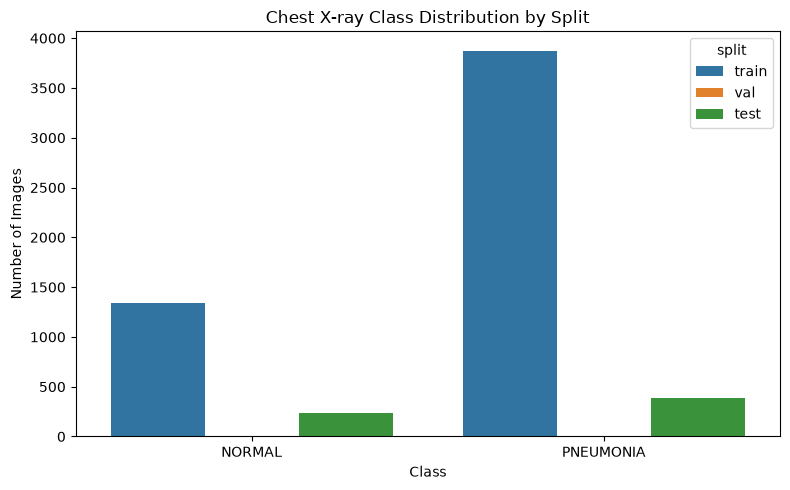

In [5]:
# Visualize the class distribution across train, validation, and test data.

plt.figure(figsize=(8, 5))
sns.countplot(data=all_raw, x="class_name", hue="split")
plt.title("Chest X-ray Class Distribution by Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Step 5 — Visualize Class Distribution

I plot the number of `NORMAL` and `PNEUMONIA` images in each split.

This is important because class imbalance can affect a binary classifier. The class distribution is considered later when calculating class weights for model training.

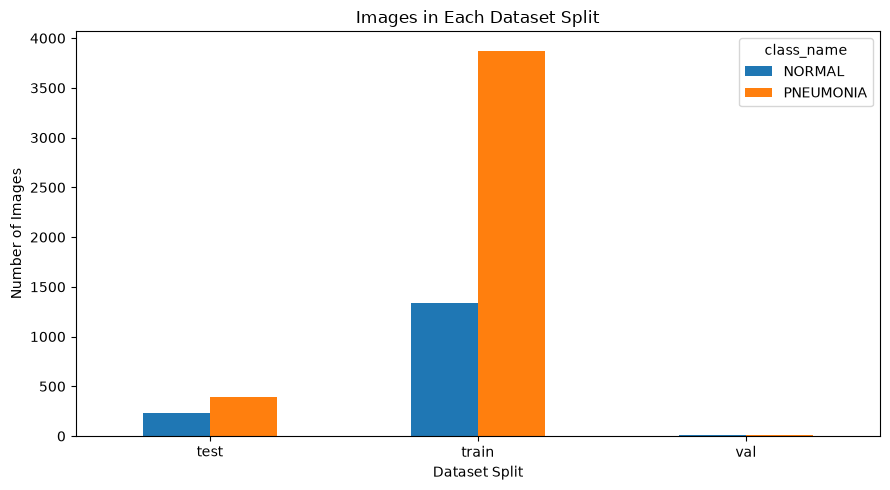

In [6]:
# Compare the number of images in each split and class.

split_counts = all_raw.groupby(["split", "class_name"]).size().unstack(fill_value=0)

ax = split_counts.plot(kind="bar", figsize=(9, 5))
ax.set_title("Images in Each Dataset Split")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 6 — Compare Dataset Splits

This visualization shows how many images belong to each class in the training, validation, and test sets.

Keeping separate validation and test data is important so that model development can be performed without using the final test set for model selection.

In [7]:
# Inspect image readability and basic file properties before model training.

def inspect_image(path):
    try:
        with Image.open(path) as img:
            return {
                "valid": True,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            }
    except Exception as exc:
        return {
            "valid": False,
            "width": None,
            "height": None,
            "mode": None,
            "format": str(exc)
        }

integrity_records = [inspect_image(p) for p in all_raw["path"]]
integrity_df = pd.DataFrame(integrity_records)

eda_df = pd.concat(
    [all_raw.reset_index(drop=True), integrity_df],
    axis=1
)

print("Invalid/corrupt images:", (~eda_df["valid"]).sum())
print("Duplicate paths:", all_raw["path"].duplicated().sum())
print("\nImage modes:")
print(eda_df["mode"].value_counts(dropna=False))

Invalid/corrupt images: 0
Duplicate paths: 0

Image modes:
mode
L      5573
RGB     283
Name: count, dtype: int64


## Step 7 — Check Image Integrity

I inspect each image using Pillow and record its:
- validity
- width and height
- color mode
- file format

I also check for duplicate image paths.

These checks help identify unreadable or unusual files before model training.

In [8]:
# Hash image contents so identical files can be detected even when their filenames or paths differ.

def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hashes = []
for path in all_raw["path"]:
    try:
        hashes.append(md5_file(path))
    except Exception:
        hashes.append(None)

all_raw["file_hash"] = hashes

duplicate_hashes = all_raw[
    all_raw["file_hash"].notna()
].duplicated("file_hash", keep=False)

print("Images involved in identical-content duplicates:", duplicate_hashes.sum())

Images involved in identical-content duplicates: 62


## Step 8 — Detect Identical-Content Duplicates

File paths alone cannot identify copies of the same image stored under different names. Therefore, I calculate an MD5 hash for each readable image.

Images with the same content produce the same hash, allowing me to flag possible identical-content duplicates and reduce the risk of unintended data leakage.

             width       height  aspect_ratio
count  5856.000000  5856.000000   5856.000000
mean   1327.880806   970.689037      1.442986
std     363.500922   383.392117      0.254356
min     384.000000   127.000000      0.835391
25%    1056.000000   688.000000      1.261627
50%    1281.000000   888.000000      1.415885
75%    1560.000000  1187.000000      1.585750
max    2916.000000  2713.000000      3.378788


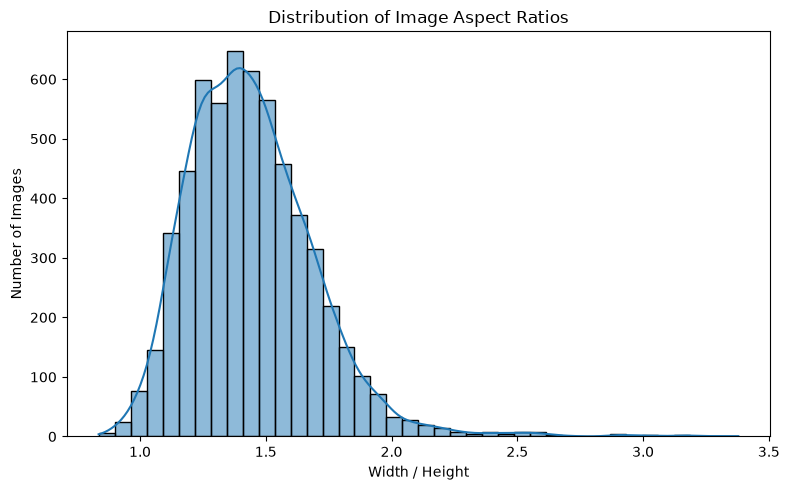

In [9]:
# Analyze original image dimensions and aspect ratios before standardizing all model inputs to 224x224.

valid_dims = eda_df[eda_df["valid"]].copy()
valid_dims["aspect_ratio"] = valid_dims["width"] / valid_dims["height"]

print(valid_dims[["width", "height", "aspect_ratio"]].describe())

plt.figure(figsize=(8, 5))
sns.histplot(valid_dims["aspect_ratio"], bins=40, kde=True)
plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Step 9 — Analyze Image Dimensions

I examine the width, height, and aspect-ratio distribution of valid images.

The model later resizes every image to **224 × 224**, so this analysis helps document the original image characteristics and the need for standardized model input.

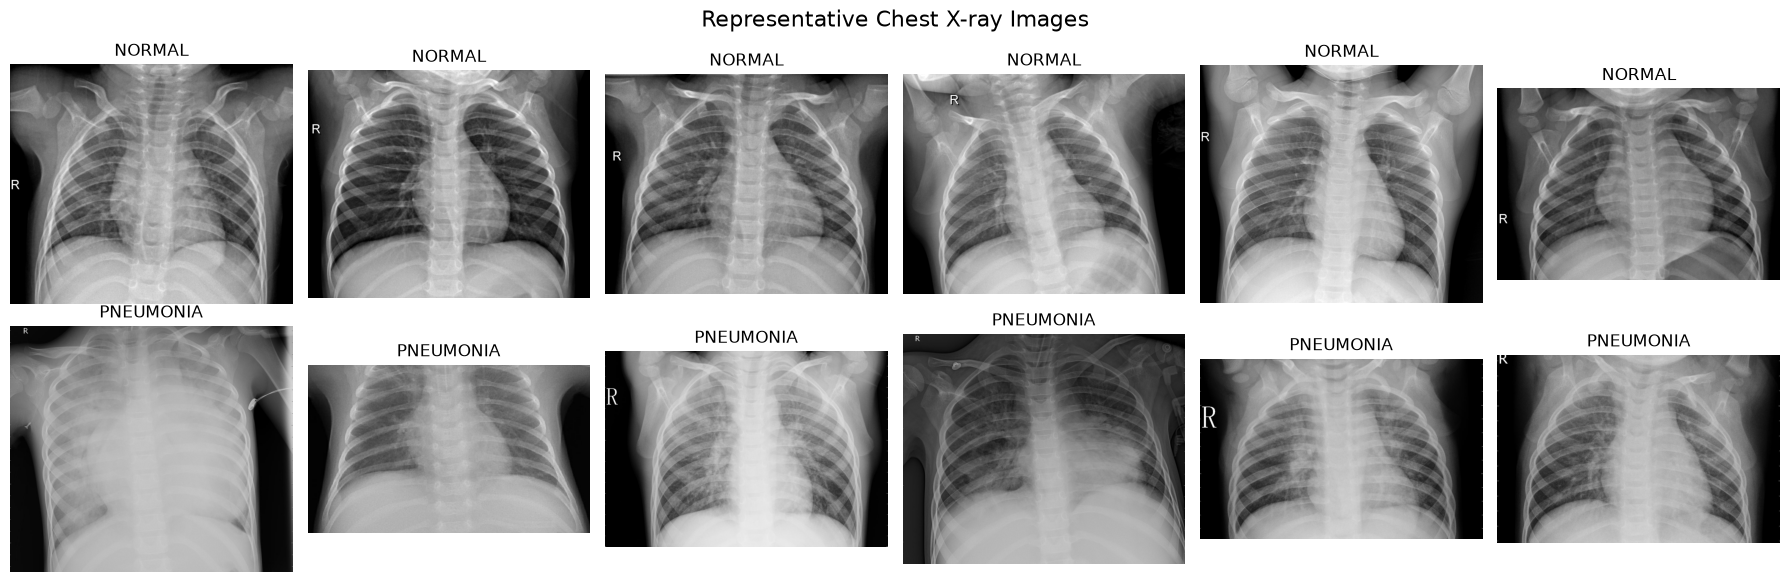

In [10]:
# Display representative examples from both target classes for a visual sanity check.

def show_samples(df, n_per_class=6, seed=SEED):
    fig, axes = plt.subplots(2, n_per_class, figsize=(18, 6))

    for row_idx, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
        subset = df[df["class_name"] == class_name]
        sample = subset.sample(min(n_per_class, len(subset)), random_state=seed)

        for col_idx, (_, row) in enumerate(sample.iterrows()):
            img = Image.open(row["path"]).convert("RGB")
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(class_name)
            axes[row_idx, col_idx].axis("off")

        for col_idx in range(len(sample), n_per_class):
            axes[row_idx, col_idx].axis("off")

    plt.suptitle("Representative Chest X-ray Images", fontsize=16)
    plt.tight_layout()
    plt.show()

show_samples(train_raw)

## Step 10 — Visualize Representative Chest X-rays

I display sample images from both classes.

This provides a visual sanity check of the dataset and helps demonstrate what the input data look like before preprocessing and augmentation.

In [11]:
# Create a stratified validation split while keeping the original test set untouched.

train_source = train_raw.drop(columns=["file_hash"], errors="ignore").copy()
test_df = test_raw.drop(columns=["file_hash"], errors="ignore").copy()

train_df, val_df = train_test_split(
    train_source,
    test_size=0.15,
    stratify=train_source["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass proportions:")
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"\n{name}")
    print(df["class_name"].value_counts(normalize=True))

Train: 4433
Validation: 783
Test: 624

Class proportions:

Train
class_name
PNEUMONIA    0.742838
NORMAL       0.257162
Name: proportion, dtype: float64

Validation
class_name
PNEUMONIA    0.743295
NORMAL       0.256705
Name: proportion, dtype: float64

Test
class_name
PNEUMONIA    0.625
NORMAL       0.375
Name: proportion, dtype: float64


## Step 11 — Prepare Train, Validation, and Test Data

The original training data are split into training and validation subsets using a **stratified split**, preserving the class proportions.

The existing test set remains separate and is used only for final evaluation.

This separation supports a cleaner estimate of generalization performance.

In [12]:
# Build an efficient TensorFlow input pipeline for reading, resizing, batching, and prefetching images.

def decode_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["path"].values,
        df["label"].values.astype("float32")
    ))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

for images, labels in train_ds.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 224, 224, 3)
Labels: (32,)


## Step 12 — Build the TensorFlow Input Pipeline

I create a `tf.data` pipeline that:
1. reads each image from disk,
2. decodes it as a 3-channel image,
3. resizes it to 224 × 224,
4. converts it to floating-point values,
5. batches the data,
6. prefetches batches for more efficient training.

The training dataset is shuffled while validation and test datasets are kept deterministic.

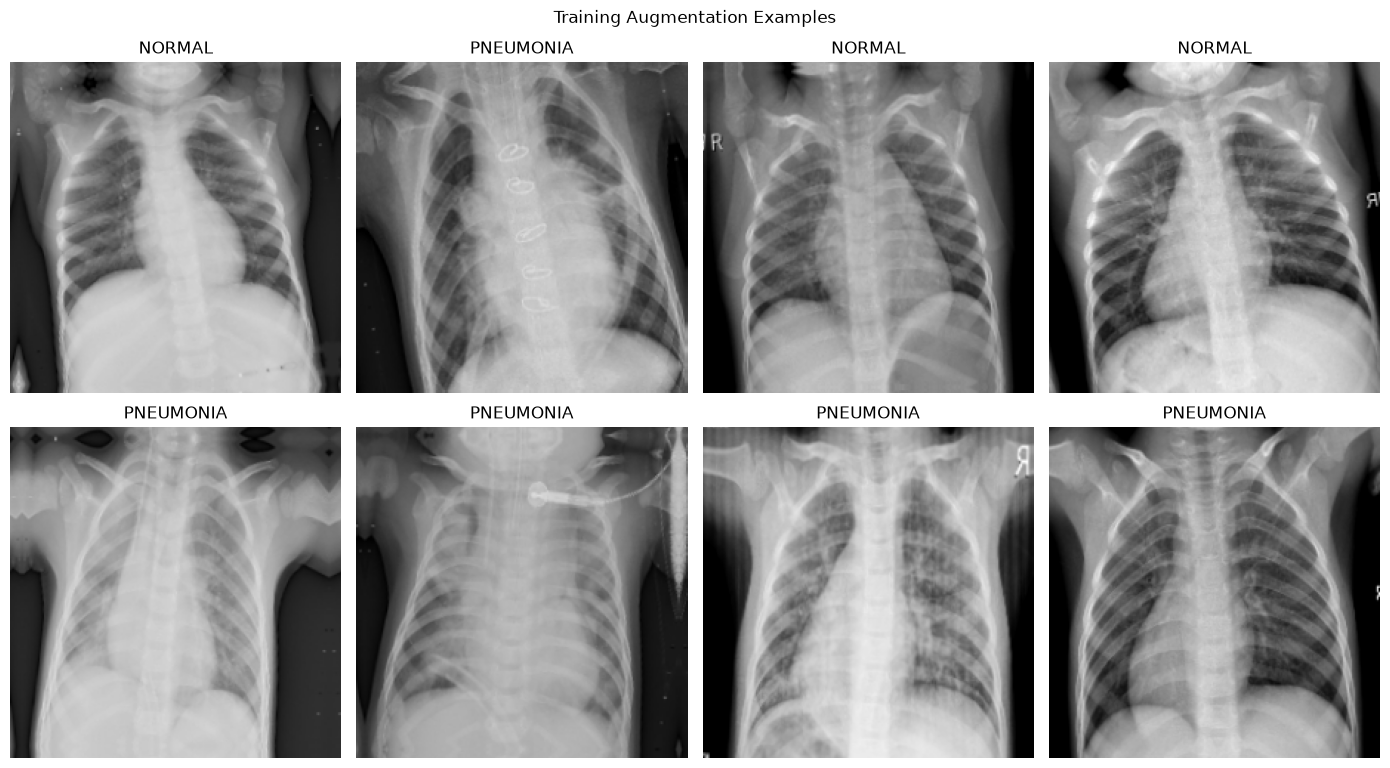

In [13]:
# Apply lightweight augmentation to improve generalization without changing the source image files.

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="xray_augmentation")

sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(14, 8))
for i in range(min(8, len(sample_images))):
    augmented = augmentation(
        tf.expand_dims(sample_images[i], 0),
        training=True
    )[0]

    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(augmented, 0, 255), tf.uint8))
    plt.title(CLASS_NAMES[int(sample_labels[i].numpy())])
    plt.axis("off")

plt.suptitle("Training Augmentation Examples")
plt.tight_layout()
plt.show()

## Step 13 — Apply Training Data Augmentation

To improve generalization, I use light image augmentation:
- horizontal flipping
- small rotations
- small zoom changes
- contrast variation

Augmentation is applied during training rather than permanently modifying the original X-ray files.

The examples below show how the augmentation changes training images.

In [14]:
# Calculate training class weights to reduce the effect of class imbalance.

class_counts = train_df["label"].value_counts().sort_index()
total = len(train_df)

class_weight = {
    int(cls): total / (2 * count)
    for cls, count in class_counts.items()
}

print("Class counts:")
print(class_counts)
print("\nClass weights:")
print(class_weight)

Class counts:
label
0    1140
1    3293
Name: count, dtype: int64

Class weights:
{0: 1.9442982456140352, 1: 0.6730944427573641}


## Step 14 — Calculate Class Weights

If the two classes are not equally represented, a model may become biased toward the larger class.

I calculate class weights from the training data and pass them to model training so that errors from underrepresented classes receive appropriate weight.

In [15]:
# Build an EfficientNetB0 transfer-learning classifier with a sigmoid output for binary prediction.

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(1, activation="sigmoid", name="pneumonia_probability")(x)

model = keras.Model(inputs, outputs, name="Pneumonia_EfficientNetB0")
model.summary()

Model: "Pneumonia_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xray_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Step 15 — Build the EfficientNetB0 Classifier

I use **EfficientNetB0 with ImageNet-pretrained weights** as the convolutional backbone.

The architecture is:
- input: 224 × 224 × 3
- augmentation
- EfficientNetB0 feature extractor
- global average pooling
- dropout regularization
- one sigmoid output for pneumonia probability

Transfer learning allows the project to start from learned visual features instead of training a deep CNN entirely from scratch.

In [16]:
# Stage 1: freeze the pretrained backbone and train the new classification head.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ]
)

callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight,
    callbacks=callbacks_stage1,
    verbose=1
)

Epoch 1/12


d:\ProjectMaterail\pneumonia_chest_xray\pneumonia_chest_xray\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8062 - auc: 0.9053 - loss: 0.4124 - pr_auc: 0.9653 - precision: 0.9319 - recall: 0.7974
Epoch 1: val_auc improved from None to 0.97715, saving model to models\pneumonia_efficientnetb0_best.keras

Epoch 1: finished saving model to models\pneumonia_efficientnetb0_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.8062 - auc: 0.9053 - loss: 0.4124 - pr_auc: 0.9653 - precision: 0.9319 - recall: 0.7974 - val_accuracy: 0.8889 - val_auc: 0.9772 - val_loss: 0.2590 - val_pr_auc: 0.9921 - val_precision: 0.9806 - val_recall: 0.8677 - learning_rate: 0.0010
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8931 - auc: 0.9659 - loss: 0.2542 - pr_auc: 0.9883 - precision: 0.9672 - recall: 0.8861
Epoch 2: val_auc improved from 0.97715 to 0.98199, saving model to models\pneumonia_efficientnetb0_best.keras

Epoch 2: finished saving model to models\pneumonia_efficientnetb0_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/s

## Step 16 — Train the Classification Head

Initially, the EfficientNetB0 backbone is frozen. Only the new classification head is trained.

I use:
- binary cross-entropy loss
- Adam optimizer
- accuracy, precision, recall
- ROC-AUC and PR-AUC
- model checkpointing
- early stopping
- learning-rate reduction
- class weights

The best model is selected using validation ROC-AUC.

In [17]:
# Unfreeze only the later backbone layers for controlled fine-tuning; keep BatchNorm frozen for stability.

base_model.trainable = True

fine_tune_from = max(0, len(base_model.layers) - 30)

for idx, layer in enumerate(base_model.layers):
    if idx < fine_tune_from or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

print("Trainable backbone layers:",
      sum(int(layer.trainable) for layer in base_model.layers))

Trainable backbone layers: 23


## Step 17 — Fine-tune the Backbone

After the initial transfer-learning stage, I unfreeze only the later EfficientNetB0 layers while keeping Batch Normalization layers frozen.

A smaller learning rate is used for fine-tuning so that pretrained features are adjusted gradually instead of being changed too aggressively.

In [18]:
# Stage 2: fine-tune with a much smaller learning rate and validation-based callbacks.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ]
)

callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9323 - auc: 0.9834 - loss: 0.1636 - pr_auc: 0.9943 - precision: 0.9798 - recall: 0.9280
Epoch 1: val_auc improved from None to 0.98928, saving model to models\pneumonia_efficientnetb0_best.keras

Epoch 1: finished saving model to models\pneumonia_efficientnetb0_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9323 - auc: 0.9834 - loss: 0.1636 - pr_auc: 0.9943 - precision: 0.9798 - recall: 0.9280 - val_accuracy: 0.9221 - val_auc: 0.9893 - val_loss: 0.1788 - val_pr_auc: 0.9959 - val_precision: 0.9924 - val_recall: 0.9021 - learning_rate: 1.0000e-05
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9364 - auc: 0.9852 - loss: 0.1531 - pr_auc: 0.9950 - precision: 0.9815 - recall: 0.9320
Epoch 2: val_auc improved from 0.98928 to 0.98991, saving model to models\pneumonia_efficientnetb0_best.keras

Epoch 2: finished saving model to models\pneumonia_efficientnetb0_best.keras
139/139 ━━━━━━━━━━━━━━━

## Step 18 — Train the Fine-tuned Model

The second training stage continues with the same evaluation metrics and protective callbacks.

The checkpoint and early-stopping strategy helps retain the best validation model rather than simply using the final epoch.

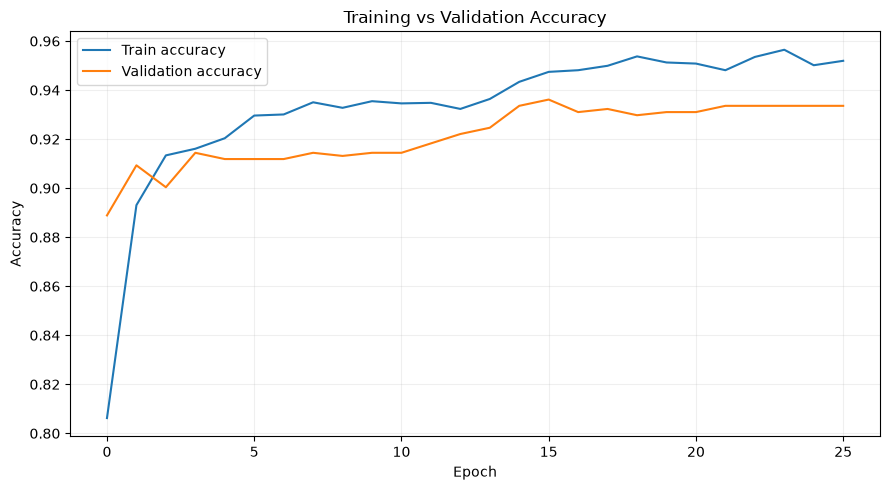

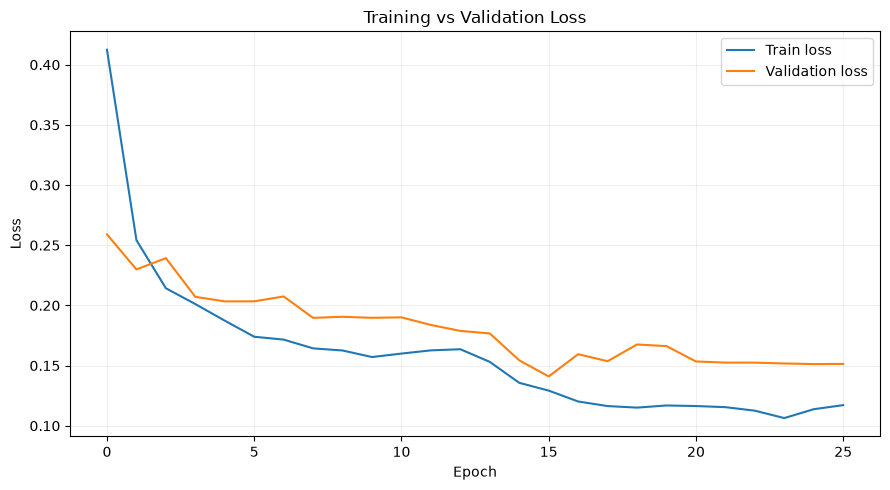

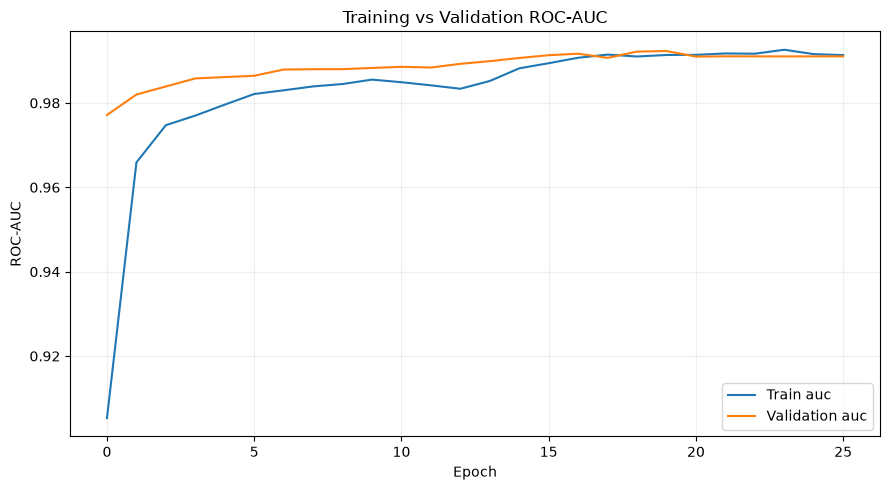

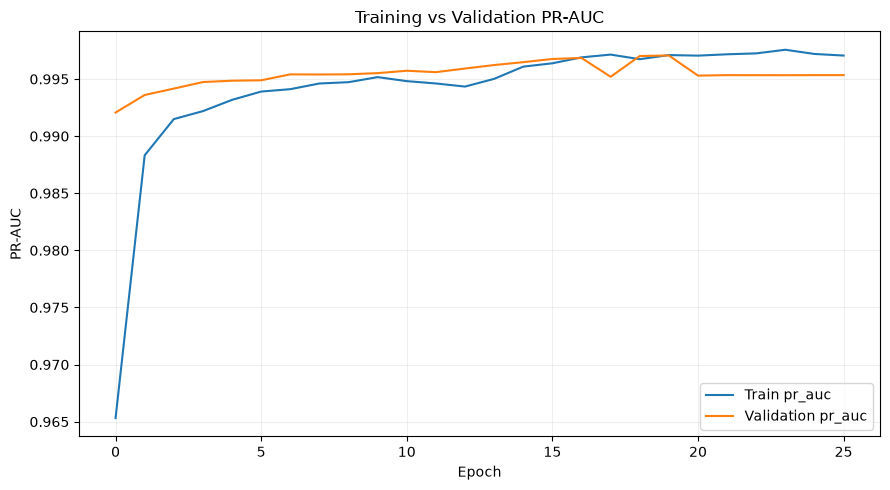

In [19]:
# Combine both training stages so the complete learning history can be visualized together.

def merge_histories(h1, h2):
    merged = {}
    for key in set(h1.history) | set(h2.history):
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history = merge_histories(history_stage1, history_stage2)

def plot_history(metric, title, ylabel):
    plt.figure(figsize=(9, 5))
    plt.plot(history[metric], label=f"Train {metric}")
    plt.plot(history[f"val_{metric}"], label=f"Validation {metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_history("accuracy", "Training vs Validation Accuracy", "Accuracy")
plot_history("loss", "Training vs Validation Loss", "Loss")
plot_history("auc", "Training vs Validation ROC-AUC", "ROC-AUC")
plot_history("pr_auc", "Training vs Validation PR-AUC", "PR-AUC")

## Step 19 — Review Training History

I combine both training stages and plot:
- accuracy
- loss
- ROC-AUC
- PR-AUC

Comparing training and validation curves helps identify learning behavior and possible overfitting.

In [20]:
# Compare final training and validation metrics to quantify the generalization gap.

train_acc_gap = history["accuracy"][-1] - history["val_accuracy"][-1]
train_auc_gap = history["auc"][-1] - history["val_auc"][-1]

print("Final training accuracy   :", round(history["accuracy"][-1], 4))
print("Final validation accuracy:", round(history["val_accuracy"][-1], 4))
print("Final training AUC        :", round(history["auc"][-1], 4))
print("Final validation AUC      :", round(history["val_auc"][-1], 4))
print("Accuracy train/val gap    :", round(train_acc_gap, 4))
print("AUC train/val gap         :", round(train_auc_gap, 4))

Final training accuracy   : 0.952
Final validation accuracy: 0.9336
Final training AUC        : 0.9913
Final validation AUC      : 0.991
Accuracy train/val gap    : 0.0184
AUC train/val gap         : 0.0003


## Step 20 — Quantify Train/Validation Gaps

I calculate the final training-versus-validation gaps for accuracy and ROC-AUC.

These values are used as a simple diagnostic to understand whether the model is showing a large generalization gap.

In [21]:
# Load the checkpoint that achieved the best validation ROC-AUC.

best_model = keras.models.load_model(BEST_MODEL_PATH) if BEST_MODEL_PATH.exists() else model
print("Using:", BEST_MODEL_PATH if BEST_MODEL_PATH.exists() else "current model")

Using: models\pneumonia_efficientnetb0_best.keras


## Step 21 — Load the Best Saved Model

I reload the model checkpoint selected using validation ROC-AUC.

This ensures the final evaluation uses the saved best-performing validation checkpoint when that file is available.

In [22]:
# Generate test probabilities and calculate the main binary-classification metrics at threshold 0.50.

y_true = test_df["label"].to_numpy().astype(int)
y_prob = best_model.predict(test_ds, verbose=1).ravel()

DEFAULT_THRESHOLD = 0.50
y_pred = (y_prob >= DEFAULT_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_true, y_pred, labels=[0, 1]
).ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) else 0.0
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall / Sensitivity",
        "Specificity", "F1 Score", "ROC-AUC", "PR-AUC"
    ],
    "Value": [
        accuracy, precision, recall, specificity, f1, roc_auc, pr_auc
    ]
})

metrics_df

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step


,Metric,Value
0,Accuracy,0.879808
1,Precision,0.860412
2,Recall / Sensitivity,0.964103
3,Specificity,0.739316
4,F1 Score,0.909311
5,ROC-AUC,0.955205
6,PR-AUC,0.970755


## Step 22 — Evaluate on the Held-out Test Set

The test set is now used for final performance measurement.

At the default threshold of **0.50**, I calculate:
- Accuracy
- Precision
- Recall / Sensitivity
- Specificity
- F1 score
- ROC-AUC
- PR-AUC

The probability scores are retained so that threshold analysis can be performed separately.

In [23]:
# Produce class-wise precision, recall, and F1 results.

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL     0.9251    0.7393    0.8219       234
   PNEUMONIA     0.8604    0.9641    0.9093       390

    accuracy                         0.8798       624
   macro avg     0.8928    0.8517    0.8656       624
weighted avg     0.8847    0.8798    0.8765       624



## Step 23 — Class-wise Performance

The classification report shows precision, recall, and F1 score separately for `NORMAL` and `PNEUMONIA`.

This is more informative than accuracy alone because it shows how the classifier behaves for each class.

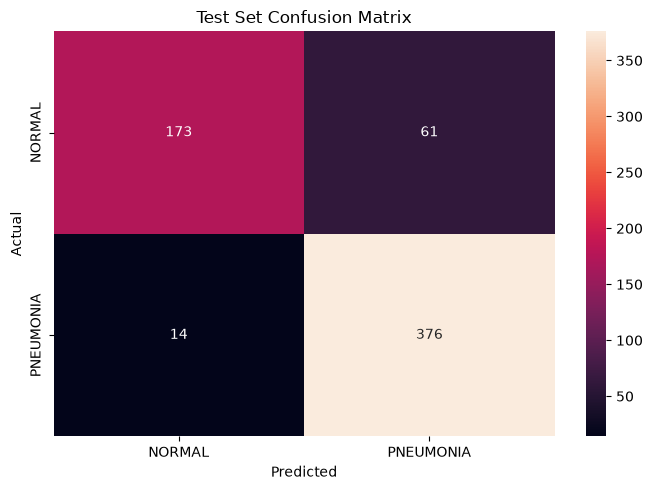

TN=173, FP=61, FN=14, TP=376


In [24]:
# Calculate and visualize the four confusion-matrix outcomes.

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

## Step 24 — Confusion Matrix

The confusion matrix separates:
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

For a pneumonia screening prototype, false negatives are particularly important to inspect because they represent pneumonia images classified as normal.

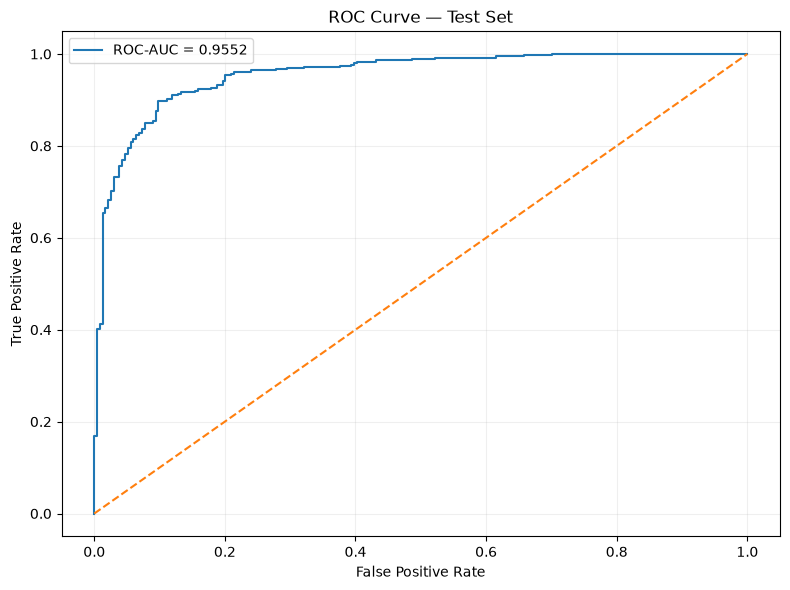

In [25]:
# Plot ROC performance across all probability thresholds.

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Step 25 — ROC Curve

The ROC curve compares the true-positive rate with the false-positive rate across different probability thresholds.

ROC-AUC summarizes the model's ranking ability across thresholds rather than evaluating only one fixed threshold.

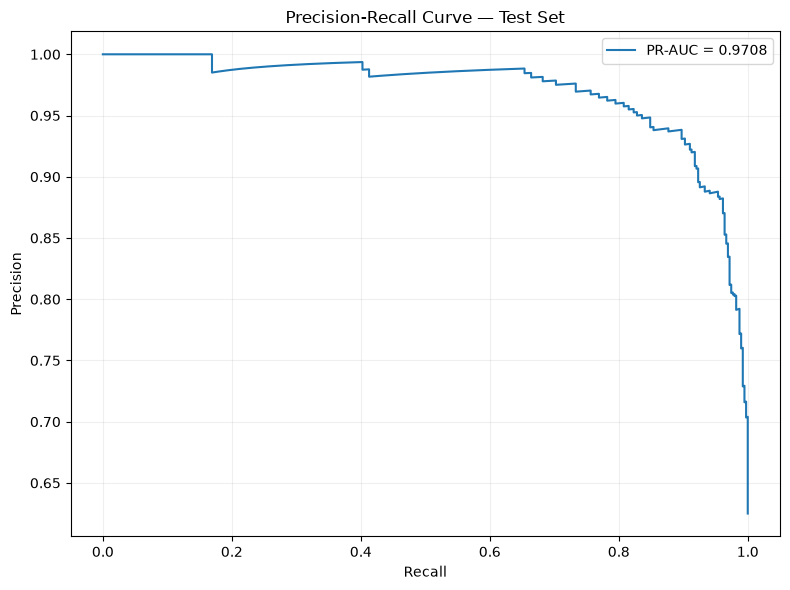

In [26]:
# Plot Precision-Recall performance across all probability thresholds.

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Test Set")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Step 26 — Precision-Recall Curve

The Precision-Recall curve examines the trade-off between precision and recall over different thresholds.

PR-AUC is useful for understanding positive-class performance, especially when the class distribution is not perfectly balanced.

25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step


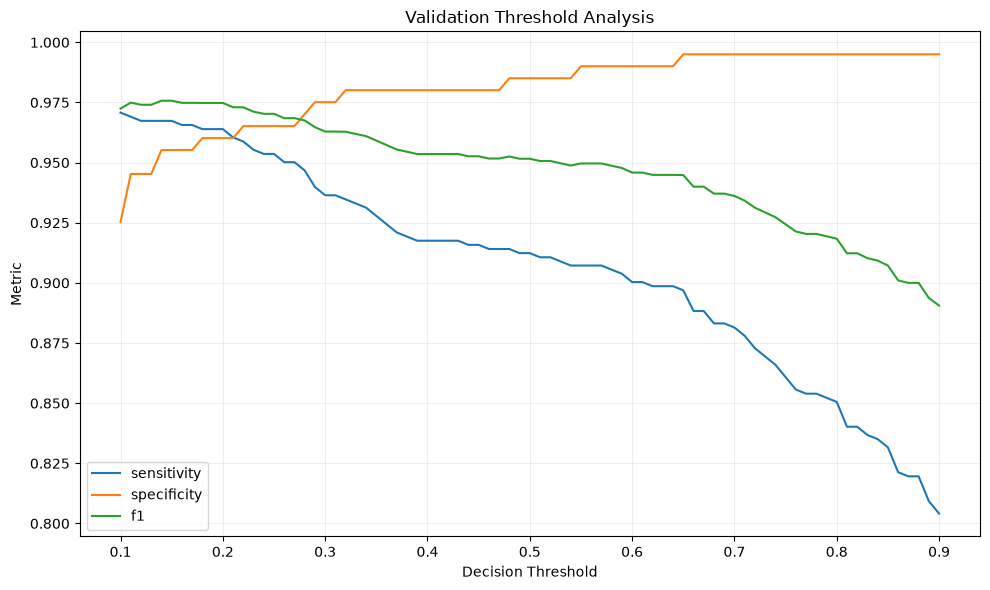

Selected threshold by maximum validation F1: 0.14


In [27]:
# Choose an operating threshold from validation data only, based on maximum validation F1.

val_true = val_df["label"].to_numpy().astype(int)
val_prob = best_model.predict(val_ds, verbose=1).ravel()

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    pred = (val_prob >= threshold).astype(int)

    tn_v, fp_v, fn_v, tp_v = confusion_matrix(
        val_true, pred, labels=[0, 1]
    ).ravel()

    sensitivity = tp_v / (tp_v + fn_v) if (tp_v + fn_v) else 0
    specificity_v = tn_v / (tn_v + fp_v) if (tn_v + fp_v) else 0
    precision_v = tp_v / (tp_v + fp_v) if (tp_v + fp_v) else 0
    f1_v = f1_score(val_true, pred, zero_division=0)

    threshold_rows.append({
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity_v,
        "precision": precision_v,
        "f1": f1_v
    })

threshold_df = pd.DataFrame(threshold_rows)

plt.figure(figsize=(10, 6))
for metric in ["sensitivity", "specificity", "f1"]:
    plt.plot(
        threshold_df["threshold"],
        threshold_df[metric],
        label=metric
    )

plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.title("Validation Threshold Analysis")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

selected_threshold = float(
    threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
)

print("Selected threshold by maximum validation F1:",
      round(selected_threshold, 2))

## Step 27 — Select a Decision Threshold Using Validation Data

A sigmoid model produces a probability, but a binary prediction requires a decision threshold.

I evaluate thresholds from 0.10 to 0.90 **using the validation set**, not the test set, and compare sensitivity, specificity, precision, and F1 score.

The threshold selected here is therefore a validation-based operating point. The test set can then be evaluated at that fixed threshold without using test labels to choose it.

In [28]:
# Apply the validation-selected threshold to the held-out test set for a second operating-point evaluation.

threshold_test_pred = (y_prob >= selected_threshold).astype(int)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(
    y_true, threshold_test_pred, labels=[0, 1]
).ravel()

threshold_test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall / Sensitivity",
        "Specificity", "F1 Score"
    ],
    "Value": [
        accuracy_score(y_true, threshold_test_pred),
        precision_score(y_true, threshold_test_pred, zero_division=0),
        recall_score(y_true, threshold_test_pred, zero_division=0),
        tn_t / (tn_t + fp_t) if (tn_t + fp_t) else 0,
        f1_score(y_true, threshold_test_pred, zero_division=0)
    ]
})

threshold_test_metrics

,Metric,Value
0,Accuracy,0.807692
1,Precision,0.768924
2,Recall / Sensitivity,0.989744
3,Specificity,0.504274
4,F1 Score,0.865471


## Step 28 — Evaluate the Selected Validation Threshold on the Test Set

I apply the threshold selected from validation data to the held-out test predictions.

This provides a second operating-point view of test performance and illustrates the trade-off between sensitivity, specificity, precision, and F1 score.

In [29]:
# Create a row-level test prediction table and identify incorrect predictions.

results_df = test_df.copy()
results_df["true_label"] = y_true
results_df["predicted_label"] = y_pred
results_df["pneumonia_probability"] = y_prob
results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

misclassified = results_df[~results_df["correct"]].copy()

print("Test images:", len(results_df))
print("Misclassified:", len(misclassified))
print("Error rate:", round(len(misclassified) / len(results_df), 4))

Test images: 624
Misclassified: 75
Error rate: 0.1202


## Step 29 — Identify Misclassified Test Images

I create a results table containing the true label, predicted label, pneumonia probability, and correctness for every test image.

I then identify the incorrectly classified cases and calculate the overall test error rate.

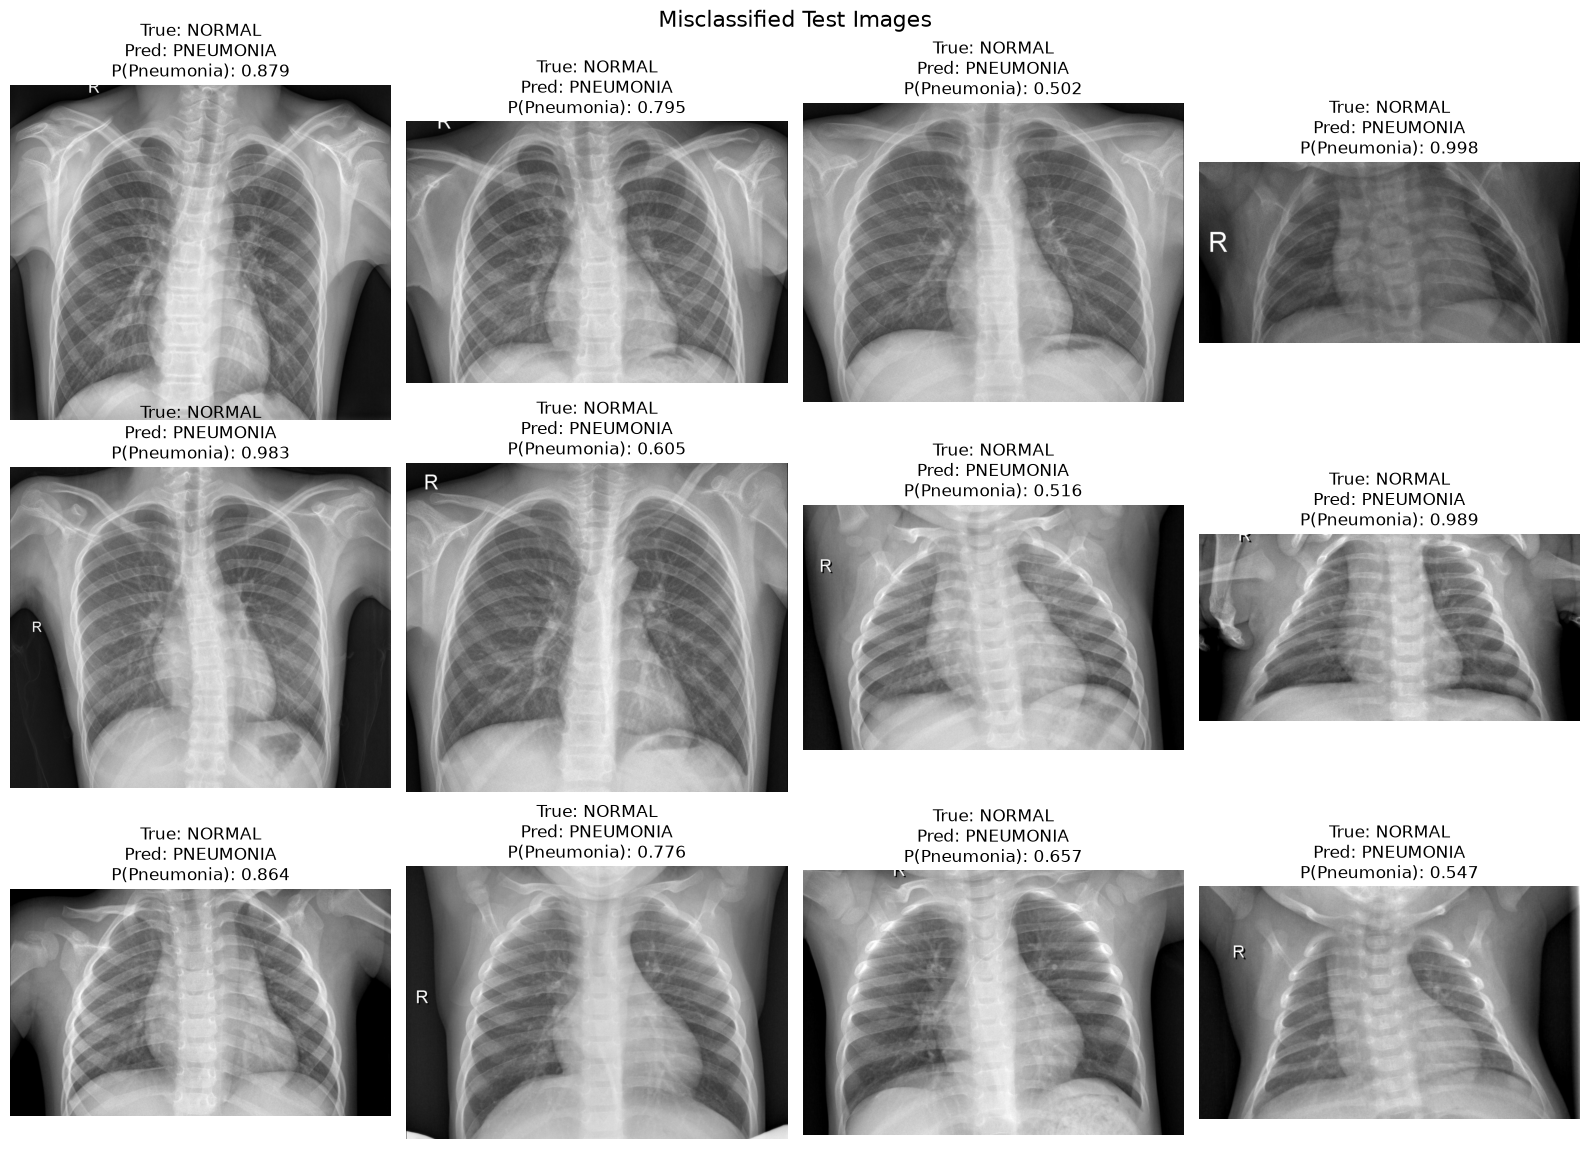

In [30]:
# Visualize representative test errors together with their true labels and model probabilities.

def show_misclassified(df, n=12):
    if len(df) == 0:
        print("No misclassified images at the default threshold.")
        return

    sample = df.head(min(n, len(df)))
    cols = 4
    rows = int(np.ceil(len(sample) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)

        true_name = CLASS_NAMES[int(row["true_label"])]
        pred_name = CLASS_NAMES[int(row["predicted_label"])]

        ax.set_title(
            f"True: {true_name}\n"
            f"Pred: {pred_name}\n"
            f"P(Pneumonia): {row['pneumonia_probability']:.3f}"
        )
        ax.axis("off")

    plt.suptitle("Misclassified Test Images", fontsize=16)
    plt.tight_layout()
    plt.show()

show_misclassified(misclassified)

## Step 30 — Inspect Misclassified Images

I display examples of misclassified X-rays with:
- true class
- predicted class
- predicted pneumonia probability

This qualitative inspection helps understand where the model struggles and provides evidence for future improvement work.

In [31]:
# Count false positives and false negatives separately for targeted error analysis.

false_positives = results_df[
    (results_df["true_label"] == 0) &
    (results_df["predicted_label"] == 1)
]

false_negatives = results_df[
    (results_df["true_label"] == 1) &
    (results_df["predicted_label"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 61
False negatives: 14


## Step 31 — Separate Error Types

I separately count:
- false positives: NORMAL predicted as PNEUMONIA
- false negatives: PNEUMONIA predicted as NORMAL

This is important because the two error types have different practical implications.

In [32]:
# Sort incorrect predictions by confidence to find strong but incorrect model decisions.

results_df["confidence"] = np.where(
    results_df["predicted_label"] == 1,
    results_df["pneumonia_probability"],
    1 - results_df["pneumonia_probability"]
)

high_confidence_errors = (
    results_df[~results_df["correct"]]
    .sort_values("confidence", ascending=False)
)

high_confidence_errors[
    [
        "path",
        "class_name",
        "predicted_label",
        "pneumonia_probability",
        "confidence"
    ]
].head(15)

,path,class_name,predicted_label,pneumonia_probability,confidence
144,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.999624,0.999624
16,Chest-Xray-2\chest_xray\test\NORMAL\IM-0022-00...,NORMAL,1,0.998058,0.998058
133,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.997891,0.997891
45,Chest-Xray-2\chest_xray\test\NORMAL\IM-0073-00...,NORMAL,1,0.989305,0.989305
134,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.988977,0.988977
143,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.986307,0.986307
20,Chest-Xray-2\chest_xray\test\NORMAL\IM-0028-00...,NORMAL,1,0.982766,0.982766
119,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.975029,0.975029
124,Chest-Xray-2\chest_xray\test\NORMAL\NORMAL2-IM...,NORMAL,1,0.974469,0.974469
581,Chest-Xray-2\chest_xray\test\PNEUMONIA\person8...,PNEUMONIA,0,0.027638,0.972362


## Step 32 — Inspect High-confidence Mistakes

I sort incorrect predictions by confidence.

High-confidence errors are useful cases for further investigation because the model was strongly convinced of the wrong class.

In [33]:
# If an external dataset is supplied, evaluate the already-trained model without retraining.

def collect_external(root):
    rows = []
    root = Path(root)

    for class_name, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        class_dir = root / class_name
        if not class_dir.exists():
            continue

        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    "path": str(path),
                    "label": label,
                    "class_name": class_name,
                    "split": "external"
                })

    return pd.DataFrame(rows)

if EXTERNAL_ROOT is None:
    print("External validation skipped: EXTERNAL_ROOT is None.")
else:
    external_df = collect_external(EXTERNAL_ROOT)

    if len(external_df) == 0:
        print("No external images found. Check EXTERNAL_ROOT.")
    else:
        external_ds = make_dataset(external_df)
        ext_true = external_df["label"].to_numpy().astype(int)
        ext_prob = best_model.predict(external_ds, verbose=1).ravel()
        ext_pred = (ext_prob >= selected_threshold).astype(int)

        ext_cm = confusion_matrix(ext_true, ext_pred, labels=[0, 1])
        ext_tn, ext_fp, ext_fn, ext_tp = ext_cm.ravel()

        external_metrics = pd.DataFrame({
            "Metric": [
                "Accuracy", "Precision", "Recall / Sensitivity",
                "Specificity", "F1 Score", "ROC-AUC", "PR-AUC"
            ],
            "Value": [
                accuracy_score(ext_true, ext_pred),
                precision_score(ext_true, ext_pred, zero_division=0),
                recall_score(ext_true, ext_pred, zero_division=0),
                ext_tn / (ext_tn + ext_fp) if (ext_tn + ext_fp) else 0,
                f1_score(ext_true, ext_pred, zero_division=0),
                roc_auc_score(ext_true, ext_prob) if len(np.unique(ext_true)) == 2 else np.nan,
                average_precision_score(ext_true, ext_prob) if len(np.unique(ext_true)) == 2 else np.nan
            ]
        })

        display(external_metrics)

External validation skipped: EXTERNAL_ROOT is None.


## Step 33 — Optional External Validation

The notebook supports an optional external dataset with the same `NORMAL` and `PNEUMONIA` folder structure.

If an external dataset path is supplied, the trained model is evaluated on those images without retraining. If no external path is configured, this section is skipped.

External validation is useful for checking whether performance transfers beyond the original dataset, although it is not a substitute for a clinical validation study.

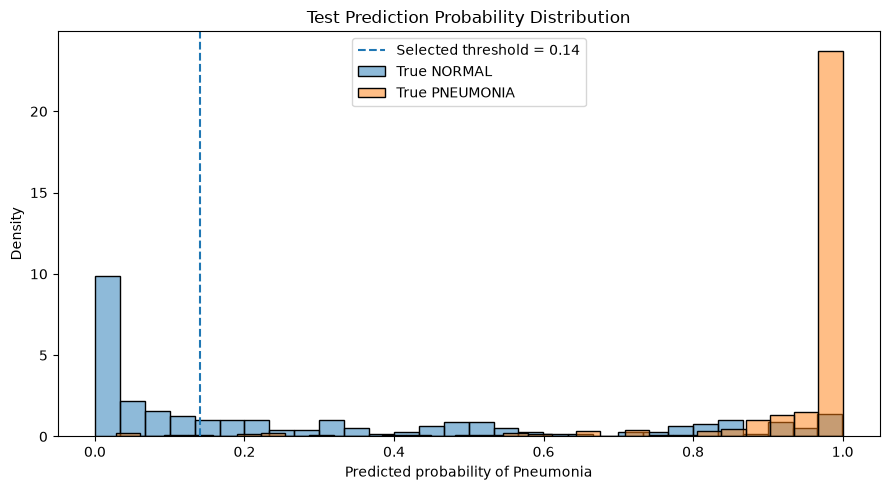

In [34]:
# Compare the probability distributions for true NORMAL and PNEUMONIA test images.

plt.figure(figsize=(9, 5))

sns.histplot(
    y_prob[y_true == 0],
    bins=30,
    stat="density",
    alpha=0.5,
    label="True NORMAL"
)

sns.histplot(
    y_prob[y_true == 1],
    bins=30,
    stat="density",
    alpha=0.5,
    label="True PNEUMONIA"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}"
)

plt.xlabel("Predicted probability of Pneumonia")
plt.ylabel("Density")
plt.title("Test Prediction Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## Step 34 — Inspect Prediction Probabilities

I visualize the predicted pneumonia probabilities for true NORMAL and true PNEUMONIA test images.

The selected validation threshold is shown on the same plot, making the separation and overlap between the two classes easier to understand.

In [35]:
# Provide a reusable function for predicting one chest X-ray image.

def predict_xray(image_path, threshold=selected_threshold, display=True):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(image_path)

    image = Image.open(image_path).convert("RGB")
    resized = image.resize(IMG_SIZE)

    arr = np.asarray(resized, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)

    probability = float(
        best_model.predict(arr, verbose=0).ravel()[0]
    )

    prediction = (
        "PNEUMONIA" if probability >= threshold else "NORMAL"
    )

    result = {
        "image": str(image_path),
        "prediction": prediction,
        "pneumonia_probability": probability,
        "normal_probability": 1 - probability,
        "threshold": threshold
    }

    if display:
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.title(
            f"Prediction: {prediction}\n"
            f"P(Pneumonia) = {probability:.3f}"
        )
        plt.axis("off")
        plt.show()

    return result


## Step 35 — Build a Reusable Single-X-ray Prediction Function

I create a helper function that accepts one image path, applies the same resizing and model prediction process, and returns:
- predicted class
- pneumonia probability
- normal probability
- decision threshold

This makes the trained model reusable for individual X-ray inference.

In [36]:
# Save the trained model and a metadata file so the result can be reused outside the notebook.

best_model.save(FINAL_MODEL_PATH)

metadata = {
    "model": "EfficientNetB0",
    "input_size": list(IMG_SIZE),
    "classes": CLASS_NAMES,
    "selected_validation_threshold": float(selected_threshold),
    "seed": SEED,
    "test_metrics_at_0_50": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc)
    },
    "medical_use": "Educational/research prototype; not a standalone clinical diagnostic system."
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Model saved to:", FINAL_MODEL_PATH.resolve())
print("Metadata saved to:", METADATA_PATH.resolve())

Model saved to: D:\ProjectMaterail\pneumonia_chest_xray\pneumonia_chest_xray\models\pneumonia_efficientnetb0_final.keras
Metadata saved to: D:\ProjectMaterail\pneumonia_chest_xray\pneumonia_chest_xray\models\pneumonia_model_metadata.json


## Step 36 — Save the Final Model and Metadata

The best model is saved in Keras format.

A metadata JSON file is also created containing the model name, input size, class mapping, selected validation threshold, random seed, test metrics at threshold 0.50, and the educational/research use statement.

These files can be used by the Flask web application developed for this project.

In [37]:
# Print the key project configuration and final test metrics for submission and documentation.

print("=" * 70)
print("PNEUMONIA CHEST X-RAY CLASSIFICATION — FINAL SUMMARY")
print("=" * 70)
print("Train images       :", len(train_df))
print("Validation images  :", len(val_df))
print("Test images        :", len(test_df))
print("Input size         :", IMG_SIZE)
print("Backbone           : EfficientNetB0")
print("Transfer learning  : Yes")
print("Fine-tuning        : Yes")
print("Augmentation       : Yes")
print("Class weighting    : Yes")
print("Selected threshold :", round(selected_threshold, 2))

print("\nTest metrics at threshold 0.50")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall/Sensitivity : {recall:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")

print("\nConfusion matrix:")
print(cm)

PNEUMONIA CHEST X-RAY CLASSIFICATION — FINAL SUMMARY
Train images       : 4433
Validation images  : 783
Test images        : 624
Input size         : (224, 224)
Backbone           : EfficientNetB0
Transfer learning  : Yes
Fine-tuning        : Yes
Augmentation       : Yes
Class weighting    : Yes
Selected threshold : 0.14

Test metrics at threshold 0.50
Accuracy           : 0.8798
Precision          : 0.8604
Recall/Sensitivity : 0.9641
Specificity        : 0.7393
F1 Score           : 0.9093
ROC-AUC            : 0.9552
PR-AUC             : 0.9708

Confusion matrix:
[[173  61]
 [ 14 376]]
